# Shishaldin event catalog 

gets full window of specified time, filters and denoises it once, runs STA/LTA once on each, and records every trigger with the same metrics as the chunked version 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from obspy import UTCDateTime, Stream
from obspy.clients.fdsn import Client
from obspy.signal.trigger import recursive_sta_lta, trigger_onset
import seisbench.models as sbm


In [29]:
# params

SOURCE = "IRIS"
NETWORK = "AV"
STATION = "SSLS"
LOCATION = ""
CHANNEL = "BH*"

START_TIME = UTCDateTime("2025-11-01T00:00:00")
STOP_TIME = UTCDateTime("2025-11-01T00:30:00")

# padding on each side of the analysis window, trimmed off after
# filtering to remove taper/edge effects
EDGE_TRIM_SECONDS = 120

# params for filtering (bandpass)
FREQMIN = 0.5
FREQMAX = 8.0
CORNERS = 2

# sta/lta parameters
STA_SECONDS = 1.5
LTA_SECONDS = 30.0
TRIGGER_ON = 3.0
TRIGGER_OFF = 1.0
STARTUP_SECONDS = 120


In [30]:
# load client to get data and model

client = Client(SOURCE)

inv = client.get_stations(
    network=NETWORK,
    station=STATION,
    level="response"
)

model = sbm.DeepDenoiser.from_pretrained("original")


/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.loa

In [31]:
# download the whole analysis window in a single request
# (padded on both sides so filtering/tapering doesn't distort the
# edges of the window we actually care about)

download_start = START_TIME - EDGE_TRIM_SECONDS
download_end = STOP_TIME + EDGE_TRIM_SECONDS

stream = client.get_waveforms(
    NETWORK,
    STATION,
    LOCATION,
    CHANNEL,
    download_start,
    download_end
)

# remove instrument response
stream.remove_response(
    inventory=inv,
    output="VEL"
)

raw_trace = stream.select(channel="BHZ")[0].copy()
raw_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

print(raw_trace)


AV.SSLS..BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-01T00:30:00.000000Z | 50.0 Hz, 90001 samples


In [32]:
# filter the full trace once

filtered_full_trace = stream.select(channel="BHZ")[0].copy()

filtered_full_trace.detrend("demean")
filtered_full_trace.detrend("linear")

# filtered_full_trace.taper(max_percentage=0.03)

filtered_full_trace.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX, corners=CORNERS, zerophase=True)

# drop the padding now that filtering/tapering is done
filtered_full_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

# want to be 30 minutes
print(filtered_full_trace)


AV.SSLS..BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-01T00:30:00.000000Z | 50.0 Hz, 90001 samples


In [33]:
# run DeepDenoiser once on the full continuous filtered trace

denoised_stream = Stream([filtered_full_trace])
denoised_full = model.annotate(denoised_stream)
denoised_full_trace = denoised_full[0].copy()

# notice upsampling
print(denoised_full_trace)


AV.SSLS..DeepDenoiser_BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-01T00:30:00.010000Z | 100.0 Hz, 180002 samples


In [34]:
# sta/lta function

def run_sta_lta(trace, sta_seconds=STA_SECONDS, lta_seconds=LTA_SECONDS, trigger_on=TRIGGER_ON, trigger_off=TRIGGER_OFF, startup_seconds=STARTUP_SECONDS):

    fs = trace.stats.sampling_rate
    nsta = int(sta_seconds * fs)
    nlta = int(lta_seconds * fs)

    cft = recursive_sta_lta(trace.data, nsta, nlta)

    # no triggers during startup period because they were bad
    startup_samples = int(startup_seconds * fs)

    cft_for_trigger = cft.copy()
    cft_for_trigger[:startup_samples] = 0
    triggers = trigger_onset(cft_for_trigger, trigger_on, trigger_off)

    return cft, triggers


In [35]:
# run STA/LTA on the continuous filtered and denoised traces

cft_filtered, triggers_filtered = run_sta_lta(filtered_full_trace)
cft_filtered_denoised, triggers_filtered_denoised = run_sta_lta(denoised_full_trace)

n_events_filtered = len(triggers_filtered)
n_events_filtered_denoised = len(triggers_filtered_denoised)

print(f"any NaNs (filtered): {np.isnan(cft_filtered).any()}")
print(f"any NaNs (denoised): {np.isnan(cft_filtered_denoised).any()}")
print(f"number of events in filtered data: {n_events_filtered}")
print(f"number of events in denoised data: {n_events_filtered_denoised}")


any NaNs (filtered): False
any NaNs (denoised): False
number of events in filtered data: 18
number of events in denoised data: 21


In [36]:
# whole-period SNR

def calculate_whole_period_snr(trace, triggers):

    data = trace.data.astype(float)

    signal_mask = np.zeros(len(data), dtype=bool)

    for on, off in triggers:
        signal_mask[on:off] = True

    signal_data = data[signal_mask]
    
    # better ways to calculate noise? 
    noise_data = data[~signal_mask]

    if len(signal_data) == 0 or len(noise_data) == 0:
        return np.nan, np.nan, np.nan

    signal_rms = np.sqrt(np.mean(signal_data ** 2))
    noise_rms = np.sqrt(np.mean(noise_data ** 2))

    if noise_rms == 0:
        snr_db = np.nan
    else:
        snr_db = 20 * np.log10(signal_rms / noise_rms)

    return signal_rms, noise_rms, snr_db


filtered_signal_rms, filtered_noise_rms, filtered_snr_db = (calculate_whole_period_snr(filtered_full_trace, triggers_filtered))

denoised_signal_rms, denoised_noise_rms, denoised_snr_db = (calculate_whole_period_snr(denoised_full_trace, triggers_filtered_denoised))

print("WHOLE-PERIOD SNR")
print("Filtered:")
print(f"  Signal RMS: {filtered_signal_rms:.6e}")
print(f"  Noise RMS:  {filtered_noise_rms:.6e}")
print(f"  SNR:        {filtered_snr_db:.2f} dB")
print()
print("Denoised:")
print(f"  Signal RMS: {denoised_signal_rms:.6e}")
print(f"  Noise RMS:  {denoised_noise_rms:.6e}")
print(f"  SNR:        {denoised_snr_db:.2f} dB")


WHOLE-PERIOD SNR
Filtered:
  Signal RMS: 1.796100e-06
  Noise RMS:  9.530803e-07
  SNR:        5.50 dB

Denoised:
  Signal RMS: 4.214799e-07
  Noise RMS:  5.843138e-08
  SNR:        17.16 dB


In [37]:
# build an event catalog containing events detected in BOTH the FILTERED and DENOISED data
# The filtered triggers are used as the event list and the filtered event is kept only if it overlaps with a denoised trigger

def get_window_metrics(trace, window_start, window_end):
    event = trace.copy()
    event.trim(starttime=window_start, endtime=window_end)

    signal_rms = np.sqrt(np.mean(event.data.astype(float) ** 2))
    max_amplitude = np.max(np.abs(event.data))

    noise = trace.copy()
    noise.trim(starttime=trace.stats.starttime, endtime=window_start)

    if len(noise.data) > 0:
        noise_rms = np.sqrt(np.mean(noise.data.astype(float) ** 2))
        snr = (
            20 * np.log10(signal_rms / noise_rms)
            if noise_rms > 0 else np.nan
        )
    else:
        noise_rms, snr = np.nan, np.nan

    return signal_rms, noise_rms, snr, max_amplitude


# get denoised triggers and use as indices

denoised_trigger_times = []
for on, off in triggers_filtered_denoised:
    denoised_start = (denoised_full_trace.stats.starttime + on / denoised_full_trace.stats.sampling_rate)
    denoised_end = (denoised_full_trace.stats.starttime + off / denoised_full_trace.stats.sampling_rate)
    denoised_trigger_times.append((denoised_start, denoised_end))

# build the catalog
rows = []

events_not_in_denoised = []
for event_number, (on, off) in enumerate(triggers_filtered, start=1):

    event_start = (filtered_full_trace.stats.starttime + on / filtered_full_trace.stats.sampling_rate)
    event_end = (filtered_full_trace.stats.starttime + off / filtered_full_trace.stats.sampling_rate)

    # check overlap in denoised triggers
    matching_denoised_event = None

    for denoised_start, denoised_end in denoised_trigger_times:

        # Check for overlap between the two time windows
        if event_start <= denoised_end and event_end >= denoised_start:
            matching_denoised_event = (denoised_start, denoised_end)
            break

    # If there is no corresponding denoised event, skip it
    if matching_denoised_event is None:
        events_not_in_denoised.append(event_number)
        continue

    # calculate metrics
    event_duration = event_end - event_start

    filtered_signal_rms, filtered_noise_rms, filtered_snr, filtered_max_amplitude = (get_window_metrics(filtered_full_trace, event_start, event_end))

    denoised_signal_rms, denoised_noise_rms, denoised_snr, denoised_max_amplitude = (get_window_metrics(denoised_full_trace, event_start, event_end))

    rows.append({
        "event_number": event_number,
        "event_start": event_start.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "event_end": event_end.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "duration_seconds": float(event_duration),

        "filtered_signal_rms": float(filtered_signal_rms),
        "filtered_noise_rms": float(filtered_noise_rms),
        "filtered_snr_db": float(filtered_snr),
        "filtered_max_amplitude": float(filtered_max_amplitude),

        "denoised_signal_rms": float(denoised_signal_rms),
        "denoised_noise_rms": float(denoised_noise_rms),
        "denoised_snr_db": float(denoised_snr),
        "denoised_max_amplitude": float(denoised_max_amplitude),
    })

event_results = pd.DataFrame(rows)

def format_float(x):
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "0.00"

    exponent = int(np.floor(np.log10(abs(x))))

    if exponent >= 3 or exponent <= -3:
        return f"{x:.2e}"
    else:
        return f"{x:.2f}"

event_results_csv = event_results.copy()
numeric_columns = event_results_csv.select_dtypes(include="number").columns

for col in numeric_columns:
    event_results_csv[col] = event_results_csv[col].map(format_float)

# save csv
event_results_csv.to_csv("shishaldin_event_metrics.csv", index=False)

print(f"filtered events detected: {len(triggers_filtered)}")
print(f"events detected in both: {len(event_results)}")
print(f"events removed: {len(events_not_in_denoised)}")

if events_not_in_denoised:
    print("filtered event numbers not detected in denoised data:", events_not_in_denoised)

print(f"events saved: {len(event_results)}")

event_results.head()

filtered events detected: 18
events detected in both: 12
events removed: 6
filtered event numbers not detected in denoised data: [6, 8, 10, 13, 14, 18]
events saved: 12


,event_number,event_start,event_end,duration_seconds,filtered_signal_rms,filtered_noise_rms,filtered_snr_db,filtered_max_amplitude,denoised_signal_rms,denoised_noise_rms,denoised_snr_db,denoised_max_amplitude
0,1,2025-11-01T00:02:16.220000,2025-11-01T00:02:21.960000,5.74,0.000001,9.247678e-07,3.831251,0.000004,4.840307e-08,1.549318e-08,9.894647,9.883614e-08
1,2,2025-11-01T00:02:42.400000,2025-11-01T00:02:51.200000,8.80,0.000002,9.470509e-07,7.552528,0.000008,8.187426e-07,8.129676e-08,20.061483,2.291932e-06
2,3,2025-11-01T00:04:20.300000,2025-11-01T00:04:28.840000,8.54,0.000002,1.029756e-06,5.840905,0.000005,6.302324e-07,1.718472e-07,11.287165,1.530996e-06
3,4,2025-11-01T00:05:16.460000,2025-11-01T00:05:24.220000,7.76,0.000003,1.075238e-06,8.177527,0.000007,6.368952e-07,2.014566e-07,9.997727,1.978795e-06
4,5,2025-11-01T00:06:55.940000,2025-11-01T00:07:02.920000,6.98,0.000002,1.094733e-06,3.797289,0.000005,6.857228e-07,2.076472e-07,10.376449,2.276115e-06


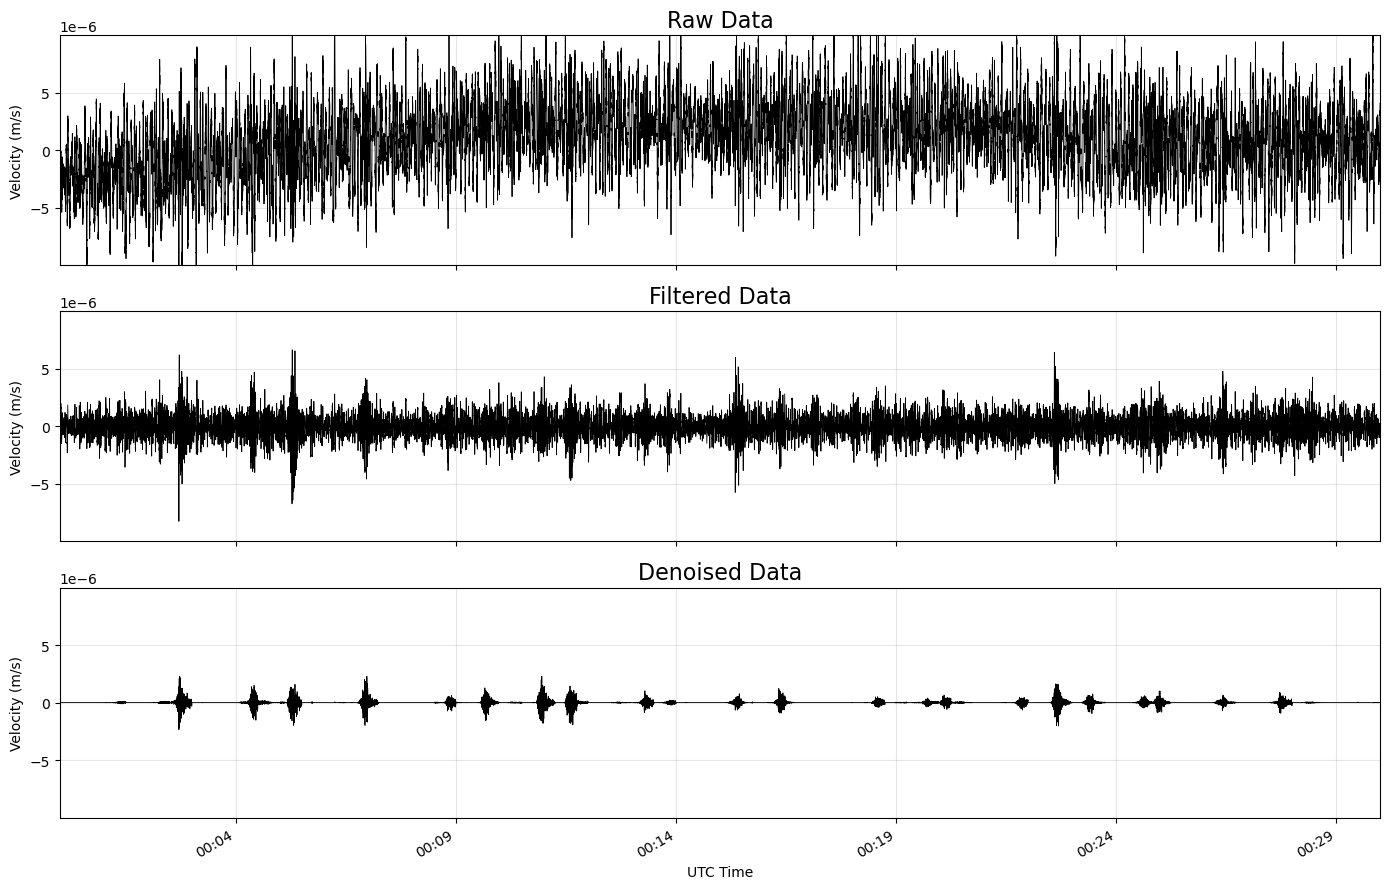

In [38]:
# plot raw / filtered / denoised waveforms

times_raw = raw_trace.times("matplotlib")
times_filtered = filtered_full_trace.times("matplotlib")
times_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(times_raw, raw_trace.data, linewidth=0.6, color="black")
axes[0].set_title("Raw Data", fontsize=16)
axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_ylim(waveform_ylim)
axes[0].set_yticks(waveform_yticks)
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_filtered, filtered_full_trace.data, linewidth=0.6, color="black")
axes[1].set_title("Filtered Data", fontsize=16)
axes[1].set_ylabel("Velocity (m/s)")
axes[1].set_ylim(waveform_ylim)
axes[1].set_yticks(waveform_yticks)
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[1].grid(True, alpha=0.3)

axes[2].plot(times_denoised, denoised_full_trace.data, linewidth=0.6, color="black")
axes[2].set_title("Denoised Data", fontsize=16)
axes[2].set_ylabel("Velocity (m/s)")
axes[2].set_xlabel("UTC Time")
axes[2].set_ylim(waveform_ylim)
axes[2].set_yticks(waveform_yticks)
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


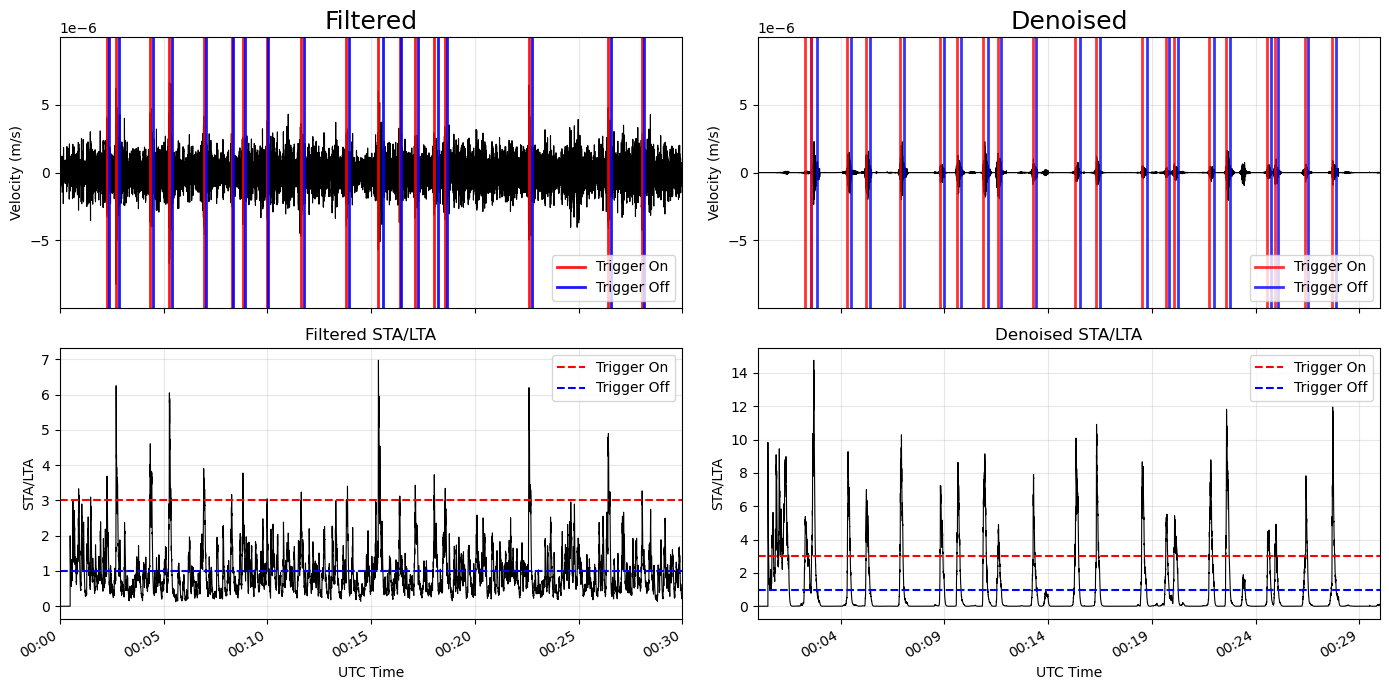

In [39]:
# plot filtered vs denoised waveforms with STA/LTA triggers

times_filtered = filtered_full_trace.times("matplotlib")
times_filtered_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")

ax = axes[0, 0]
ax.plot(times_filtered, filtered_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Filtered", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))

for i, (on, off) in enumerate(triggers_filtered):
    ax.axvline(times_filtered[on], color="red", linewidth=2, alpha=0.9,
               label="Trigger On" if i == 0 else None)
    ax.axvline(times_filtered[off], color="blue", linewidth=2, alpha=0.9,
               label="Trigger Off" if i == 0 else None)

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(times_filtered_denoised, denoised_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Denoised", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, 6))

for i, (on, off) in enumerate(triggers_filtered_denoised):
    ax.axvline(times_filtered_denoised[on], color="red", linewidth=2, alpha=0.8,
               label="Trigger On" if i == 0 else None)
    ax.axvline(times_filtered_denoised[off], color="blue", linewidth=2, alpha=0.8,
               label="Trigger Off" if i == 0 else None)

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(times_filtered, cft_filtered, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Filtered STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(times_filtered_denoised, cft_filtered_denoised, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Denoised STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


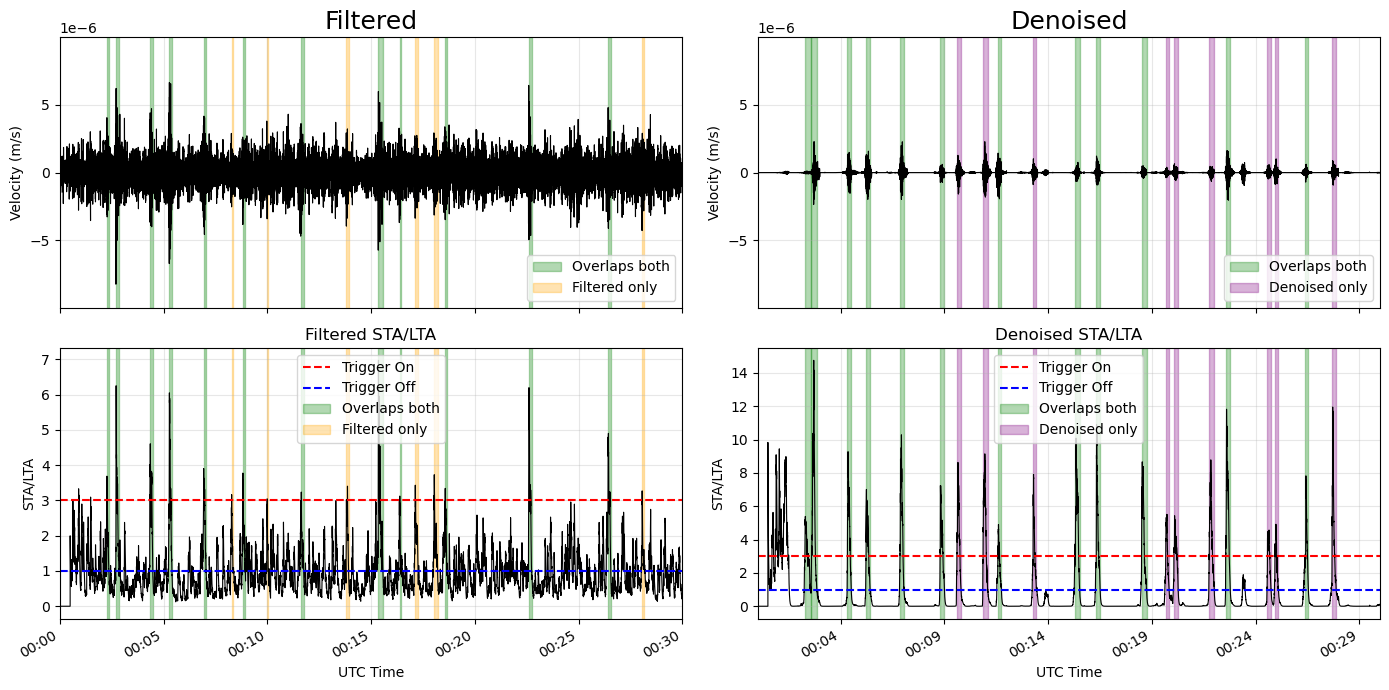

In [40]:
# plot filtered vs denoised waveforms with STA/LTA triggers,
# shaded by whether the event overlaps between filtered and denoised detections

def to_mpl(t):
    return t.matplotlib_date

def intervals_overlap(a_start, a_end, b_start, b_end):
    return a_start < b_end and b_start < a_end

# convert triggers to UTCDateTime intervals
filtered_intervals = [
    (filtered_full_trace.stats.starttime + on / filtered_full_trace.stats.sampling_rate,
     filtered_full_trace.stats.starttime + off / filtered_full_trace.stats.sampling_rate,)
    for on, off in triggers_filtered]

denoised_intervals = [
    (denoised_full_trace.stats.starttime + on / denoised_full_trace.stats.sampling_rate,
     denoised_full_trace.stats.starttime + off / denoised_full_trace.stats.sampling_rate,)
    for on, off in triggers_filtered_denoised]

# flag whether each event has a match in the other trace's detections
filtered_overlap_flags = [any(intervals_overlap(fs, fe, ds, de) for ds, de in denoised_intervals)
    for fs, fe in filtered_intervals]

denoised_overlap_flags = [any(intervals_overlap(ds, de, fs, fe) for fs, fe in filtered_intervals)
    for ds, de in denoised_intervals]

OVERLAP_COLOR = "green"
FILTERED_ONLY_COLOR = "orange"
DENOISED_ONLY_COLOR = "purple"

def shade_events(ax, intervals, overlap_flags, only_label):
    seen_overlap = False
    seen_only = False
    for (start, end), overlaps in zip(intervals, overlap_flags):
        color = OVERLAP_COLOR if overlaps else (
            FILTERED_ONLY_COLOR if only_label == "Filtered only" else DENOISED_ONLY_COLOR
        )
        label = None
        if overlaps and not seen_overlap:
            label = "Overlaps both"
            seen_overlap = True
        elif not overlaps and not seen_only:
            label = only_label
            seen_only = True
        ax.axvspan(to_mpl(start), to_mpl(end), color=color, alpha=0.3, label=label)


times_filtered = filtered_full_trace.times("matplotlib")
times_filtered_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")

ax = axes[0, 0]
ax.plot(times_filtered, filtered_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Filtered", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
shade_events(ax, filtered_intervals, filtered_overlap_flags, "Filtered only")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(times_filtered_denoised, denoised_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Denoised", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, 6))
shade_events(ax, denoised_intervals, denoised_overlap_flags, "Denoised only")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(times_filtered, cft_filtered, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
shade_events(ax, filtered_intervals, filtered_overlap_flags, "Filtered only")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Filtered STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(times_filtered_denoised, cft_filtered_denoised, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
shade_events(ax, denoised_intervals, denoised_overlap_flags, "Denoised only")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Denoised STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [41]:
# print overlap counts

n_filtered_overlap = sum(filtered_overlap_flags)
n_filtered_only = len(filtered_overlap_flags) - n_filtered_overlap

n_denoised_overlap = sum(denoised_overlap_flags)
n_denoised_only = len(denoised_overlap_flags) - n_denoised_overlap

print("EVENT OVERLAP SUMMARY")
print(f"filtered events total:     {len(filtered_intervals)}")
print(f"  overlapping w/ denoised: {n_filtered_overlap}")
print(f"  filtered only:           {n_filtered_only}")
print()
print(f"denoised events total:     {len(denoised_intervals)}")
print(f"  overlapping w/ filtered: {n_denoised_overlap}")
print(f"  denoised only:           {n_denoised_only}")

EVENT OVERLAP SUMMARY
filtered events total:     18
  overlapping w/ denoised: 12
  filtered only:           6

denoised events total:     21
  overlapping w/ filtered: 12
  denoised only:           9


count    9.000000
mean     7.331111
std      1.271814
min      5.020000
25%      6.640000
50%      7.400000
75%      8.200000
max      9.320000
Name: duration_seconds, dtype: float64


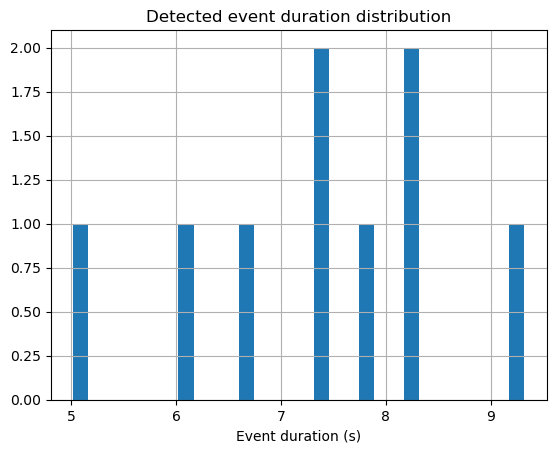

In [28]:
# inspect event durations
print(event_results["duration_seconds"].describe())
event_results["duration_seconds"].hist(bins=30)
plt.xlabel("Event duration (s)")
plt.title("Detected event duration distribution")
plt.show()

In [ ]:
# inspect the filtered-only events: how close did the denoised trace
# come to triggering during that same time window?

print("FILTERED-ONLY EVENTS")

for (start, end), overlaps in zip(filtered_intervals, filtered_overlap_flags):
    if overlaps:
        continue

    on_idx = int((start - denoised_full_trace.stats.starttime) * denoised_full_trace.stats.sampling_rate)
    off_idx = int((end - denoised_full_trace.stats.starttime) * denoised_full_trace.stats.sampling_rate)
    on_idx = max(on_idx, 0)
    off_idx = min(off_idx, len(cft_filtered_denoised))

    window_cft = cft_filtered_denoised[on_idx:off_idx]
    peak_cft = np.nanmax(window_cft) if len(window_cft) else np.nan

    print(
        f"{start} - {end}  "
        f"(duration {end - start:.2f}s)  "
        f"peak denoised STA/LTA in window: {peak_cft:.2f}  "
        f"(trigger threshold: {TRIGGER_ON})"
    )